# 16 — User 666 vs 33634: Encoding B channel divergence

Compare **baseline User 666** (near-zero residual divergence) with **extreme user 33634**  
(temporal taste-shifter from notebook 15) using the same Encoding B RBMs trained in notebook 13.

| Part | Section |
|------|--------|
| Part 0 | Setup |
| Part 1 | Build Encoding B visible vectors for target users |
| Part 2 | Divergence summary + cohort context |
| Part 3 | Hidden activation scatter (h1 vs h2) |
| Part 4 | Side-by-side divergence bar |
| Part 5 | Whiteboard Alg quadrant matrix (per-user h₁/h₂) |
| Part 6 | e₊ / e₋ movie summary (Encoding A, per user) |

**Prerequisites:** notebooks 09, 12–13 (`data/processed/` artifacts).

In [7]:
# Part 0 — Setup
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"font.size": 12})

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

proc = root / "data" / "processed"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
rating_path = root / "data" / "rating.csv"

RATING_LEVELS = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0], dtype=np.float64)
K = len(RATING_LEVELS)
rating_to_idx = {float(r): i for i, r in enumerate(RATING_LEVELS)}
CHUNK_SIZE = 1_000_000
CSV_DTYPES = {"userId": "int32", "movieId": "int32", "rating": "float32"}

TARGET_USERS = [666, 33634]
USER_LABELS = {666: "666 (baseline)", 33634: "33634 (taste-shifter)"}
USER_COLORS = {666: "#4C72B0", 33634: "#C44E52"}

movie_vocab = np.load(proc / "movie_vocab.npy").astype(int)
cohort_ids = np.load(proc / "cohort_user_ids.npy").astype(int)
vocab_set = set(movie_vocab.tolist())
movie_to_col = {int(mid): j for j, mid in enumerate(movie_vocab)}
n_movies = len(movie_vocab)

print(f"Movie vocab: {n_movies}")
print(f"Cohort size: {len(cohort_ids)}")
print(f"User 666 in cohort: {666 in set(cohort_ids.tolist())}")

Movie vocab: 2000
Cohort size: 51
User 666 in cohort: True


## Part 1 — Build Encoding B visible vectors for target users

In [8]:
# Part 1 — Build Encoding B visible vectors for target users

def round_to_half_star(x):
    r = float(np.round(float(x) * 2.0) / 2.0)
    return float(np.clip(r, 0.5, 5.0))


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


# Population means for vocab movies (full dataset)
movie_sum = defaultdict(float)
movie_cnt = defaultdict(int)
print(f"Streaming {rating_path.name} for population means (vocab) …")
for chunk in pd.read_csv(rating_path, usecols=["movieId", "rating"], dtype=CSV_DTYPES, chunksize=CHUNK_SIZE):
    sub = chunk[chunk["movieId"].isin(vocab_set)]
    if sub.empty:
        continue
    grp = sub.groupby("movieId")["rating"]
    for mid, s in grp.sum().items():
        movie_sum[int(mid)] += float(s)
    for mid, c in grp.count().items():
        movie_cnt[int(mid)] += int(c)

pop_onehot_col = np.zeros((n_movies, K), dtype=np.float32)
for j, mid in enumerate(movie_vocab):
    mu_r = round_to_half_star(movie_sum[mid] / movie_cnt[mid])
    pop_onehot_col[j, rating_to_idx[mu_r]] = 1.0

# User ratings for target users
target_set = set(TARGET_USERS)
user_ratings: dict[int, dict[int, float]] = {uid: {} for uid in TARGET_USERS}
print(f"Streaming {rating_path.name} for users {TARGET_USERS} …")
for chunk in pd.read_csv(rating_path, dtype=CSV_DTYPES, chunksize=CHUNK_SIZE):
    sub = chunk[chunk["userId"].isin(target_set) & chunk["movieId"].isin(vocab_set)]
    for uid, mid, rating in zip(sub["userId"].astype(int), sub["movieId"].astype(int), sub["rating"].astype(float)):
        user_ratings[int(uid)][int(mid)] = float(rating)

for uid in TARGET_USERS:
    print(f"  userId={uid}: {len(user_ratings[uid])} ratings in vocab")


def build_visible_vectors(uid: int) -> tuple[np.ndarray, np.ndarray]:
    """Return flattened v1 (user rating) and v2 (population mean) for one user."""
    ch1 = np.zeros((n_movies, K), dtype=np.float32)
    ch2 = np.zeros((n_movies, K), dtype=np.float32)
    for mid, r in user_ratings[uid].items():
        j = movie_to_col[mid]
        k1 = rating_to_idx[float(r)]
        ch1[j, k1] = 1.0
        ch2[j, :] = pop_onehot_col[j]
    return ch1.reshape(-1), ch2.reshape(-1)


user_vectors = {uid: build_visible_vectors(uid) for uid in TARGET_USERS}

Streaming rating.csv for population means (vocab) …
Streaming rating.csv for users [666, 33634] …
  userId=666: 63 ratings in vocab
  userId=33634: 230 ratings in vocab


## Part 2 — Divergence summary + cohort context

In [9]:
# Part 2 — Divergence summary + cohort context
W1 = np.load(proc / "rbmB1_weights_final.npy")
W2 = np.load(proc / "rbmB2_weights_final.npy")
b1 = np.load(proc / "rbmB1_bias_hidden_final.npy")
b2 = np.load(proc / "rbmB2_bias_hidden_final.npy")
channelB1 = np.load(proc / "channelB1_softmax.npy")
channelB2 = np.load(proc / "channelB2_softmax.npy")

# Cohort divergence (precomputed tensors)
cohort_div = []
for i in range(len(cohort_ids)):
    v1 = channelB1[i].reshape(-1)
    v2 = channelB2[i].reshape(-1)
    h1 = sigmoid(v1 @ W1 + b1)
    h2 = sigmoid(v2 @ W2 + b2)
    cohort_div.append(float(np.mean(np.abs(h1 - h2))))
cohort_div = np.array(cohort_div)
cohort_median = float(np.median(cohort_div))
cohort_mean = float(np.mean(cohort_div))

rows = []
hidden_cache = {}
for uid in TARGET_USERS:
    v1, v2 = user_vectors[uid]
    h1 = sigmoid(v1 @ W1 + b1)
    h2 = sigmoid(v2 @ W2 + b2)
    hidden_cache[uid] = (h1, h2)
    div = float(np.mean(np.abs(h1 - h2)))
    pct = float(100 * (cohort_div < div).mean())
    rows.append({
        "userId": uid,
        "label": USER_LABELS[uid],
        "n_vocab_ratings": len(user_ratings[uid]),
        "divergence": div,
        "cohort_percentile": pct,
        "vs_cohort_median": div - cohort_median,
    })

compare_df = pd.DataFrame(rows)
print("=== Divergence: mean(|h1 - h2|) over hidden units ===")
print(f"Cohort (n={len(cohort_ids)}): mean={cohort_mean:.4f}  median={cohort_median:.4f}")
display(compare_df)

u666 = compare_df.loc[compare_df["userId"] == 666, "divergence"].iloc[0]
u33634 = compare_df.loc[compare_df["userId"] == 33634, "divergence"].iloc[0]
ratio = u33634 / u666 if u666 > 0 else np.nan
print(f"\n33634 / 666 divergence ratio: {ratio:.2f}x")
if u33634 > u666:
    print("→ 33634 shows HIGHER channel divergence than baseline 666.")
else:
    print("→ 33634 does NOT exceed 666 on channel divergence (taste shift ≠ dual-channel split).")

=== Divergence: mean(|h1 - h2|) over hidden units ===
Cohort (n=51): mean=0.0313  median=0.0218


,userId,label,n_vocab_ratings,divergence,cohort_percentile,vs_cohort_median
0,666,666 (baseline),63,0.026350,58.823529,0.004505
1,33634,33634 (taste-shifter),230,0.300654,100.000000,0.278809



33634 / 666 divergence ratio: 11.41x
→ 33634 shows HIGHER channel divergence than baseline 666.


## Part 3 — Hidden activation scatter (h1 vs h2)

/var/folders/8l/bqykkvkj5vz4ffw8hmxk7p1w0000gn/T/ipykernel_3456/3246921782.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


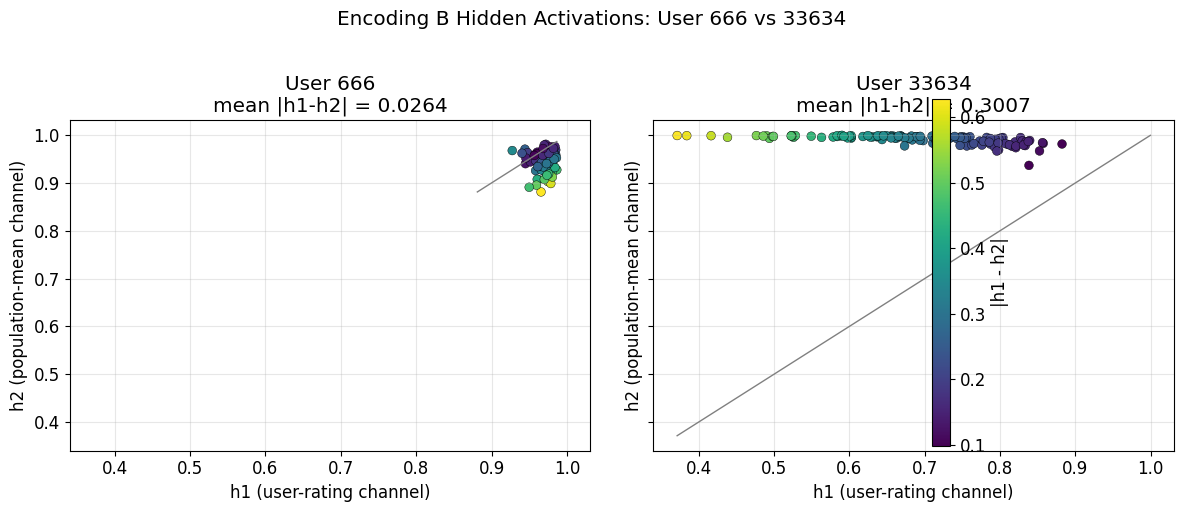

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/user666_vs_33634_activation_scatter.png


In [10]:
# Part 3 — Hidden activation scatter (h1 vs h2)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, uid in zip(axes, TARGET_USERS):
    h1, h2 = hidden_cache[uid]
    dist = np.abs(h1 - h2)
    lo = float(min(h1.min(), h2.min()))
    hi = float(max(h1.max(), h2.max()))
    ax.plot([lo, hi], [lo, hi], color="gray", lw=1, ls="-")
    sc = ax.scatter(h1, h2, c=dist, cmap="viridis", s=40, edgecolors="k", linewidths=0.3)
    ax.set_xlabel("h1 (user-rating channel)")
    ax.set_ylabel("h2 (population-mean channel)")
    ax.set_title(f"User {uid}\nmean |h1-h2| = {dist.mean():.4f}")
    ax.grid(alpha=0.3)

fig.colorbar(sc, ax=axes, label="|h1 - h2|", shrink=0.9)
fig.suptitle("Encoding B Hidden Activations: User 666 vs 33634", y=1.02)
fig.tight_layout()
path_scatter = out_dir / "user666_vs_33634_activation_scatter.png"
fig.savefig(path_scatter, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {path_scatter}")

## Part 4 — Divergence bar: targets vs cohort

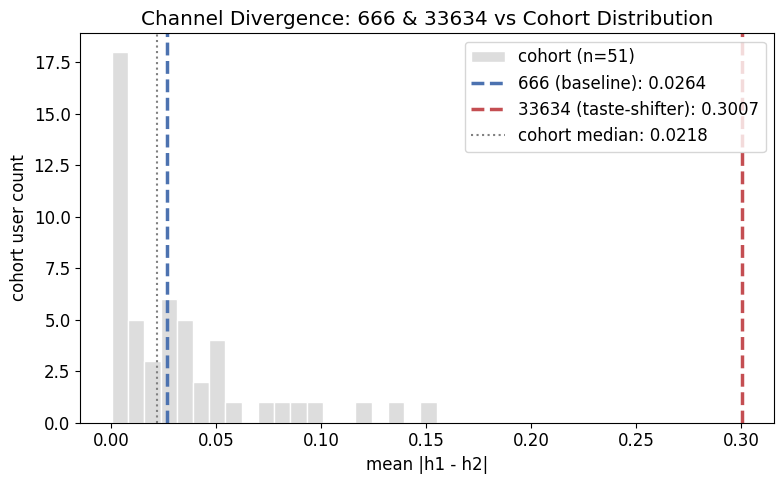

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/user666_vs_33634_divergence.png


In [11]:
# Part 4 — Divergence bar: targets vs cohort
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(cohort_div, bins=20, color="#DDDDDD", edgecolor="white", label=f"cohort (n={len(cohort_ids)})")
for uid in TARGET_USERS:
    div = compare_df.loc[compare_df["userId"] == uid, "divergence"].iloc[0]
    ax.axvline(div, color=USER_COLORS[uid], lw=2.5, ls="--", label=f"{USER_LABELS[uid]}: {div:.4f}")
ax.axvline(cohort_median, color="gray", lw=1.5, ls=":", label=f"cohort median: {cohort_median:.4f}")

ax.set_xlabel("mean |h1 - h2|")
ax.set_ylabel("cohort user count")
ax.set_title("Channel Divergence: 666 & 33634 vs Cohort Distribution")
ax.legend(loc="upper right")
fig.tight_layout()
path_bar = out_dir / "user666_vs_33634_divergence.png"
fig.savefig(path_bar, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {path_bar}")

## Part 5 — Whiteboard Alg quadrant matrix (per-user hidden units)

Map each hidden unit to the four **Alg** cells using user-centered deviations  
\(\Delta_1 \propto h_1 - \bar h_1\), \(\Delta_2 \propto h_2 - \bar h_2\) — same sign rules as notebook 11 on \(\Delta W\).

**Outputs:** printed 2×2 tables + **Figure 1** side-by-side heatmaps + **Figure 2** stacked bar  
(`outputs/user666_vs_33634_alg_matrix.png`, `user666_vs_33634_alg_quadrants.png`).

=== Whiteboard Alg ↔ hidden-unit quadrant mapping ===
Proxy: Δ₁ = h₁ − mean(h₁),  Δ₂ = h₂ − mean(h₂)  (per user, per hidden unit)

Quadrant           Δ₁     Δ₂  Alg rule
--------------------------------------------------------------
no_flip             ↑      ↑  ΔE > 0 → nothing
flip_delta2         ↑      ↓  JΔE > 0 → change Δ₂ only
flip_delta1         ↓      ↑  JΔE < 0 → change Δ₁ only
flip_both           ↓      ↓  ΔE < 0 → change both (Δ₁ & Δ₂)

=== Per-user quadrant counts (hidden units) ===


,userId,label,no_flip,flip_both,flip_delta2,flip_delta1,zero,total,mixed_sign_ratio
0,666,666 (baseline),40,25,35,28,0,128,0.492188
1,33634,33634 (taste-shifter),23,3,41,61,0,128,0.796875



=== Per-user quadrant proportions ===


,userId,label,p_no_flip,p_flip_both,p_flip_delta2,p_flip_delta1,p_zero,mixed_sign_ratio
0,666,666 (baseline),31.2%,19.5%,27.3%,21.9%,0.0%,0.492
1,33634,33634 (taste-shifter),18.0%,2.3%,32.0%,47.7%,0.0%,0.797



=== User 666 — 2×2 Alg matrix (128 hidden units) ===
                      Δ₂ above user mean     Δ₂ below user mean
Δ₁ above user mean     40  no_flip           35  flip_delta2
Δ₁ below user mean     28  flip_delta1       25  flip_both

=== User 33634 — 2×2 Alg matrix (128 hidden units) ===
                      Δ₂ above user mean     Δ₂ below user mean
Δ₁ above user mean     23  no_flip           41  flip_delta2
Δ₁ below user mean     61  flip_delta1        3  flip_both

=== Comparison vs whiteboard Alg ===
  666:    no_flip 31.2%   mixed_sign_ratio 0.492
  33634:  no_flip 18.0%   mixed_sign_ratio 0.797
→ 33634 has MORE single-channel opposition (flip_delta1/2) in hidden space.
→ 33634 has LESS aligned no_flip; channels disagree more often than baseline 666.


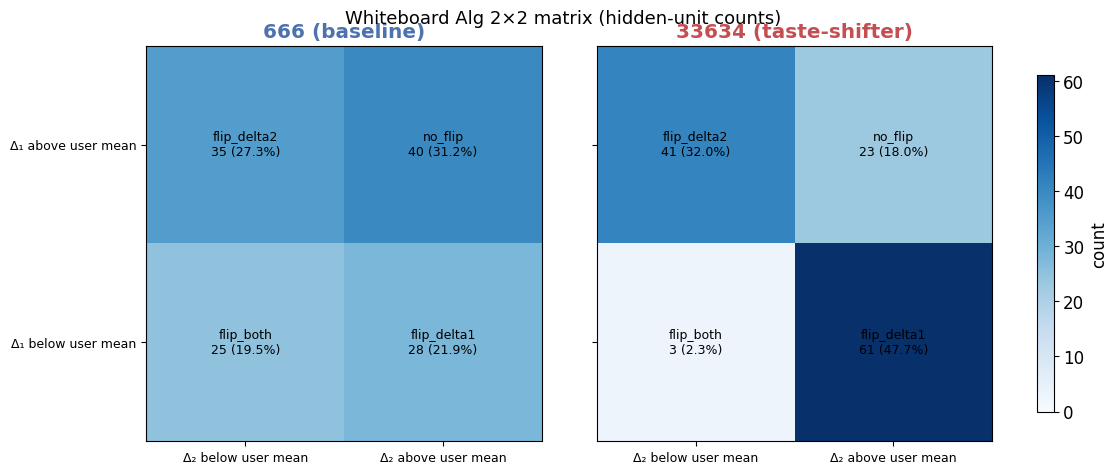

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/user666_vs_33634_alg_matrix.png


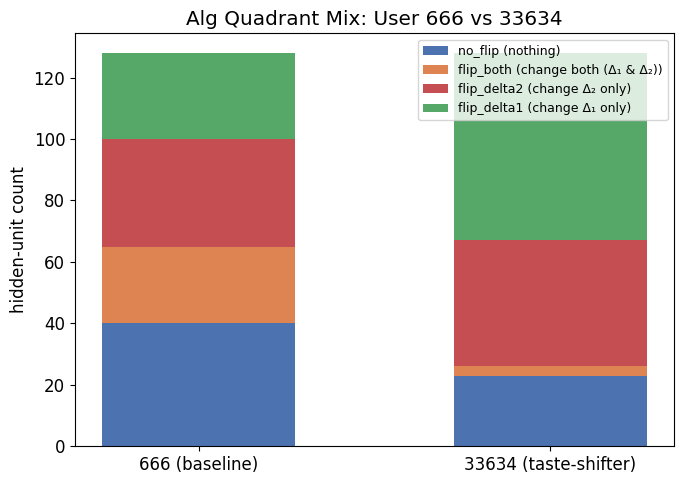

Saved: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/outputs/user666_vs_33634_alg_quadrants.png


In [12]:
# Part 5 — Whiteboard Alg quadrant matrix from user hidden activations
QUAD_COLS = ["no_flip", "flip_both", "flip_delta2", "flip_delta1"]
QUAD_COLORS = {
    "no_flip": "#4C72B0",
    "flip_both": "#DD8452",
    "flip_delta1": "#55A868",
    "flip_delta2": "#C44E52",
}
ALG_RULES = {
    "no_flip": "ΔE > 0 → nothing",
    "flip_both": "ΔE < 0 → change both (Δ₁ & Δ₂)",
    "flip_delta2": "JΔE > 0 → change Δ₂ only",
    "flip_delta1": "JΔE < 0 → change Δ₁ only",
}


def classify_user_quadrants(h1: np.ndarray, h2: np.ndarray, eps: float = 1e-12) -> dict:
    """Classify hidden units into Alg quadrants (notebook 11 rules on centered h1/h2)."""
    d1 = h1 - np.mean(h1)
    d2 = h2 - np.mean(h2)
    s1 = np.sign(d1)
    s2 = np.sign(d2)
    zero_mask = (np.abs(d1) <= eps) | (np.abs(d2) <= eps)
    active = ~zero_mask
    n = len(h1)
    counts = {
        "no_flip": int(np.sum(active & (s1 > 0) & (s2 > 0))),
        "flip_both": int(np.sum(active & (s1 < 0) & (s2 < 0))),
        "flip_delta2": int(np.sum(active & (s1 > 0) & (s2 < 0))),
        "flip_delta1": int(np.sum(active & (s1 < 0) & (s2 > 0))),
        "zero": int(np.sum(zero_mask)),
        "total": n,
    }
    non_zero = n - counts["zero"]
    for key in QUAD_COLS + ["zero"]:
        counts[f"p_{key}"] = counts[key] / n
    counts["mixed_sign_ratio"] = (
        (counts["flip_delta1"] + counts["flip_delta2"]) / non_zero if non_zero > 0 else np.nan
    )
    return counts


quad_rows = []
for uid in TARGET_USERS:
    h1, h2 = hidden_cache[uid]
    quad_rows.append({"userId": uid, "label": USER_LABELS[uid], **classify_user_quadrants(h1, h2)})
quad_df = pd.DataFrame(quad_rows)

print("=== Whiteboard Alg ↔ hidden-unit quadrant mapping ===")
print("Proxy: Δ₁ = h₁ − mean(h₁),  Δ₂ = h₂ − mean(h₂)  (per user, per hidden unit)\n")
print(f"{'Quadrant':<14} {'Δ₁':>6} {'Δ₂':>6}  Alg rule")
print("-" * 62)
print(f"{'no_flip':<14} {'↑':>6} {'↑':>6}  {ALG_RULES['no_flip']}")
print(f"{'flip_delta2':<14} {'↑':>6} {'↓':>6}  {ALG_RULES['flip_delta2']}")
print(f"{'flip_delta1':<14} {'↓':>6} {'↑':>6}  {ALG_RULES['flip_delta1']}")
print(f"{'flip_both':<14} {'↓':>6} {'↓':>6}  {ALG_RULES['flip_both']}")

print("\n=== Per-user quadrant counts (hidden units) ===")
display(quad_df[["userId", "label"] + QUAD_COLS + ["zero", "total", "mixed_sign_ratio"]])

print("\n=== Per-user quadrant proportions ===")
prop_df = quad_df[["userId", "label"] + [f"p_{c}" for c in QUAD_COLS] + ["p_zero", "mixed_sign_ratio"]].copy()
for col in [f"p_{c}" for c in QUAD_COLS] + ["p_zero"]:
    prop_df[col] = prop_df[col].map(lambda x: f"{100 * x:.1f}%")
prop_df["mixed_sign_ratio"] = prop_df["mixed_sign_ratio"].map(lambda x: f"{x:.3f}")
display(prop_df)

for uid in TARGET_USERS:
    row = quad_df.loc[quad_df["userId"] == uid].iloc[0]
    print(f"\n=== User {uid} — 2×2 Alg matrix ({int(row['total'])} hidden units) ===")
    print(f"{'':20s}  Δ₂ above user mean     Δ₂ below user mean")
    print(
        f"{'Δ₁ above user mean':20s}  "
        f"{int(row['no_flip']):3d}  no_flip          "
        f"{int(row['flip_delta2']):3d}  flip_delta2"
    )
    print(
        f"{'Δ₁ below user mean':20s}  "
        f"{int(row['flip_delta1']):3d}  flip_delta1      "
        f"{int(row['flip_both']):3d}  flip_both"
    )
    if int(row["zero"]) > 0:
        print(f"  (ties at user mean: {int(row['zero'])} units → zero bucket)")

u666_msr = quad_df.loc[quad_df["userId"] == 666, "mixed_sign_ratio"].iloc[0]
u33634_msr = quad_df.loc[quad_df["userId"] == 33634, "mixed_sign_ratio"].iloc[0]
u666_nf = quad_df.loc[quad_df["userId"] == 666, "p_no_flip"].iloc[0]
u33634_nf = quad_df.loc[quad_df["userId"] == 33634, "p_no_flip"].iloc[0]
print("\n=== Comparison vs whiteboard Alg ===")
print(f"  666:    no_flip {100*u666_nf:.1f}%   mixed_sign_ratio {u666_msr:.3f}")
print(f"  33634:  no_flip {100*u33634_nf:.1f}%   mixed_sign_ratio {u33634_msr:.3f}")
if u33634_msr > u666_msr:
    print("→ 33634 has MORE single-channel opposition (flip_delta1/2) in hidden space.")
if u33634_nf < u666_nf:
    print("→ 33634 has LESS aligned no_flip; channels disagree more often than baseline 666.")

# --- Figure 1: side-by-side 2×2 Alg heatmaps (counts + %) ---
MATRIX_QUADS = [
    ("no_flip", 0, 1),
    ("flip_delta2", 0, 0),
    ("flip_delta1", 1, 1),
    ("flip_both", 1, 0),
]
row_labels = ["Δ₁ above user mean", "Δ₁ below user mean"]
col_labels = ["Δ₂ below user mean", "Δ₂ above user mean"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True, constrained_layout=True)
for ax, uid in zip(axes, TARGET_USERS):
    row = quad_df.loc[quad_df["userId"] == uid].iloc[0]
    mat = np.zeros((2, 2), dtype=float)
    ann = [["" for _ in range(2)] for _ in range(2)]
    for quad, r, c in MATRIX_QUADS:
        cnt = int(row[quad])
        mat[r, c] = cnt
        pct = 100 * cnt / row["total"]
        ann[r][c] = f"{quad}\n{cnt} ({pct:.1f}%)"
    im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=quad_df[QUAD_COLS].to_numpy().max())
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(col_labels, fontsize=9)
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_title(USER_LABELS[uid], color=USER_COLORS[uid], fontweight="bold")
    for r in range(2):
        for c in range(2):
            ax.text(c, r, ann[r][c], ha="center", va="center", fontsize=9, color="black")
fig.suptitle("Whiteboard Alg 2×2 matrix (hidden-unit counts)", y=1.02, fontsize=13)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label="count")
path_matrix = out_dir / "user666_vs_33634_alg_matrix.png"
fig.savefig(path_matrix, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {path_matrix}")

# --- Figure 2: stacked bar — quadrant mix per user ---
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(TARGET_USERS))
bottom = np.zeros(len(TARGET_USERS))
for col in QUAD_COLS:
    vals = quad_df[col].to_numpy(dtype=float)
    ax.bar(
        x,
        vals,
        bottom=bottom,
        width=0.55,
        label=f"{col} ({ALG_RULES[col].split('→')[1].strip()})",
        color=QUAD_COLORS[col],
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([USER_LABELS[uid] for uid in TARGET_USERS])
ax.set_ylabel("hidden-unit count")
ax.set_title("Alg Quadrant Mix: User 666 vs 33634")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
path_quad = out_dir / "user666_vs_33634_alg_quadrants.png"
fig.savefig(path_quad, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {path_quad}")

## Part 6 — e₊ / e₋ movie summary (Encoding A)

Per rated movie: **e₊ = r** (liking), **e₋ = 5.5 − r** (mirror pole).  
Same movie carries both; lists below show where each pole is strongest.

**Encoding B note (Parts 1–5):** channel 1 ≈ e₊ (user rating), channel 2 ≈ population mean (external reference).

In [2]:
# Part 6 — e₊ / e₋ movie summary (Encoding A)
ENCODING_A_SUM = 5.5
MOVIE_PATH = root / "data" / "movie.csv"
USER666_PATH = root / "data" / "user_666_ratings.csv"
TOP_N = 6

movies_df = pd.read_csv(MOVIE_PATH)


def load_user_ratings_full(uid: int) -> pd.DataFrame:
    if uid == 666:
        u = pd.read_csv(USER666_PATH)
    else:
        chunks = []
        for chunk in pd.read_csv(rating_path, dtype=CSV_DTYPES, chunksize=CHUNK_SIZE):
            sub = chunk[chunk["userId"] == uid]
            if not sub.empty:
                chunks.append(sub)
        u = pd.concat(chunks, ignore_index=True)
    u = u.merge(movies_df[["movieId", "title", "genres"]], on="movieId", how="left")
    u["e_plus"] = u["rating"].astype(float)
    u["e_minus"] = ENCODING_A_SUM - u["e_plus"]
    return u


def pop_means_for_movies(movie_ids: set[int]) -> dict[int, float]:
    sums: dict[int, float] = defaultdict(float)
    cnts: dict[int, int] = defaultdict(int)
    for chunk in pd.read_csv(rating_path, usecols=["movieId", "rating"], dtype=CSV_DTYPES, chunksize=CHUNK_SIZE):
        sub = chunk[chunk["movieId"].isin(movie_ids)]
        if sub.empty:
            continue
        grp = sub.groupby("movieId")["rating"]
        for mid, s in grp.sum().items():
            sums[int(mid)] += float(s)
        for mid, c in grp.count().items():
            cnts[int(mid)] += int(c)
    return {mid: sums[mid] / cnts[mid] for mid in sums}


def show_user_e_channel_summary(uid: int, u: pd.DataFrame, pop_mean: dict[int, float]) -> None:
    u = u.copy()
    u["pop_mean"] = u["movieId"].map(pop_mean)
    u["vs_pop"] = u["rating"] - u["pop_mean"]
    cols = ["title", "genres", "rating", "e_minus", "pop_mean", "vs_pop"]

    print(f"\n{'#' * 72}")
    print(f"# USER {uid} — {USER_LABELS[uid]}")
    print(f"# ratings: n={len(u)}   mean score={u['rating'].mean():.2f}")
    print(f"{'#' * 72}")

    print(f"\n--- e₊ HIGH (likes: e₊ = r) — up to {TOP_N} at 5★ ---")
    display(u[u["rating"] == 5.0].head(TOP_N)[cols])

    print(f"--- e₋ HIGH (mirror 5.5−r: lowest ratings) — bottom {TOP_N} ---")
    display(u.nsmallest(TOP_N, "rating")[cols])

    print("--- Contrarian e₊: user >> population ---")
    display(u.nlargest(TOP_N, "vs_pop")[cols])

    print("--- Contrarian e₋: user << population ---")
    display(u.nsmallest(TOP_N, "vs_pop")[cols])

    print("--- Genre means ---")
    genre_rows = []
    for genre in ["Mystery", "War", "Comedy", "Drama", "Action", "Horror"]:
        sub = u[u["genres"].astype(str).str.contains(genre, na=False)]
        if len(sub):
            genre_rows.append({"genre": genre, "n": len(sub), "mean_rating": round(sub["rating"].mean(), 2)})
    if genre_rows:
        display(pd.DataFrame(genre_rows))


print("=== Encoding A: e₊ = r,  e₋ = 5.5 − r  (midpoint 2.75) ===")
print("Each movie has BOTH components; high e₊ = liked, high e₋ = disliked.\n")

all_movie_ids: set[int] = set()
user_frames: dict[int, pd.DataFrame] = {}
for uid in TARGET_USERS:
    print(f"Loading user {uid} …")
    u = load_user_ratings_full(uid)
    user_frames[uid] = u
    all_movie_ids.update(u["movieId"].astype(int).tolist())
    print(f"  → {len(u)} ratings loaded")

print(f"\nComputing population means for {len(all_movie_ids)} movies …")
pop_mean_map = pop_means_for_movies(all_movie_ids)
print("Done.\n")

for uid in TARGET_USERS:
    show_user_e_channel_summary(uid, user_frames[uid], pop_mean_map)

print("\n=== Side-by-side takeaway ===")
m666 = user_frames[666]["rating"].mean()
m33634 = user_frames[33634]["rating"].mean()
print(f"  666:    mean rating {m666:.2f} — e₊ on mainstream favorites; e₋ on a few comedies (Kingpin, Devil's Own).")
print(f"  33634:  mean rating {m33634:.2f} — e₊ on action/niche picks; e₋ on crowd-loved war/drama classics (0.5★).")
print("  → 33634's e₊ and population channel (Encoding B) disagree often → high divergence in Parts 2 & 5.")

=== Encoding A: e₊ = r,  e₋ = 5.5 − r  (midpoint 2.75) ===


Each movie has BOTH components; high e₊ = liked, high e₋ = disliked.


Loading user 666 …


  → 68 ratings loaded


Loading user 33634 …


...

genre,n,mean_rating
Mystery,15,3.00
War,15,2.70
Comedy,120,2.92
Drama,78,2.36
Action,85,3.54
Horror,9,3.67



=== Side-by-side takeaway ===


  666:    mean rating 3.90 — e₊ on mainstream favorites; e₋ on a few comedies (Kingpin, Devil's Own).


  33634:  mean rating 2.97 — e₊ on action/niche picks; e₋ on crowd-loved war/drama classics (0.5★).


  → 33634's e₊ and population channel (Encoding B) disagree often → high divergence in Parts 2 & 5.
